<a href="https://colab.research.google.com/github/jjyjung/ai_semicon/blob/main/src/dnn/tf_keras_DNN_BMI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.layers import Dense, Input, Dropout  # 모듈(변수나 함수를 포함)만 불러오기

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# ## PC의 Jupyter Notebook에서 실행할 때 사용하는 코드
# ## Jupyter Notebook에서 실행시킬 때에는 아래 2개 셀 대신에 이 셀을 실행하세요.

# # BMI 데이터를 읽기
# dir = "./"  # 현재 경로에 bmi.csv가 저장되어 있다고 가정함
# df = pd.read_csv(dir + "bmi.csv")    ### [중요!!] https://github.com/jjyjung/ai/blob/gh-pages/bmi.csv 에서 다운받을 수 있습니다.

In [ ]:
### Colab에서 Google Drive에 저장된 파일에 접근할 때 필요한 코드
from google.colab import drive
drive.mount('/content/gdrive')   # google drive를 google colab에 연결. 처음 실행 시, 인증 필요

# BMI 데이터를 읽어서 Data Frame으로 저장하기
dir = "/content/gdrive/My Drive/Colab Notebooks/ai/DNN/"  ### [중요!!] Colab의 경우, bmi.csv를 저장할 위치를 기록하시오.
DATA_PATH = Path(dir + "bmi.csv")    ### [중요!!] https://github.com/jjyjung/ai/blob/gh-pages/bmi.csv 에서 다운받을 수 있습니다.
DATA_URL = 'https://raw.githubusercontent.com/jjyjung/ai/gh-pages/bmi.csv'

df = pd.read_csv(DATA_PATH if DATA_PATH.exists() else DATA_URL)
df.head()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,height,weight,label
0,142,62,fat
1,142,73,fat
2,177,61,normal
3,187,48,thin
4,153,60,fat


In [ ]:
# 몸무게와 키 데이터 약식 정규화
df["weight"] /= 100   # normalization
df["height"] /= 200   # normalization
X = df[["weight", "height"]].to_numpy(dtype=np.float32)

# 레이블링, 라벨링 (labelling) => one-hot encoding
bclass = {"thin":[1,0,0], "normal":[0,1,0], "fat":[0,0,1]}
y = np.empty((20000,3))     # 20000x3 크기의 다차원 벡터 생성
for i, v in enumerate(df["label"]):
    y[i] = bclass[v]        # "thin'이면, y[i]=[1,0,0] 와 같이 할당

# 훈련 전용 데이터와 테스트 전용 데이터로 나누기
X_train, y_train = X[0:15000], y[0:15000]
X_test,  y_test  = X[15000:20000], y[15000:20000]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((15000, 2), (15000, 3), (5000, 2), (5000, 3))

In [ ]:
print(type(X_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
X_train

array([[0.62 , 0.71 ],
       [0.73 , 0.71 ],
       [0.61 , 0.885],
       ...,
       [0.54 , 0.965],
       [0.8  , 0.865],
       [0.38 , 0.955]], dtype=float32)

In [ ]:
# 모델 구조 정의하기
model = tf.keras.Sequential([
    Input(shape=(2,)),               # 입력 2개로부터 전달받음
    Dense(8, activation='relu'),     # ReLU 활성화함수 채택
    Dropout(0.1),                    # dropout ratio=10% (훈련시 10% arc 무시)
    Dense(4, activation='relu'),
    Dropout(0.1),
    Dense(3, activation='softmax'),  # 분류을 위해 softmax 함수 사용
])

# 모델 구축하기
model.compile(
    loss='categorical_crossentropy',  # 다중 교차엔트로피
    optimizer=tf.keras.optimizers.RMSprop(),   # 최적화 기법 중 하나 (tf.keras.optimizers.RMSprop(learning_rate=0.1)
    metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75 (300.00 B)

 Trainable params: 75 (300.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 'val_loss'를 monitor하여 감소하면 10회 더 참고 조기중지
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

# 데이터 훈련하기
hist = model.fit(
    X_train, y_train,
    batch_size=100,       # 100개에 한 번씩 업데이터 실행
    epochs=50,            # 훈련 데이터셋을 총 60회 반복 실험. 단, 조기중지될 수 있음
    validation_split=0.2, # validation data 분할 비율. 즉, 15000개 중에서 10%인 1500개를 validation용으로 분할
    callbacks=[early_stopping],
    verbose=1)   # 전 과정을 화면에 출력(1) 또는 미출력(0) 모드

# 테스트 데이터로 평가하기
score = model.evaluate(X_test, y_test)
print('test_loss: ', score[0])
print('test_acc: ', score[1])

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3347 - loss: 1.0830 - val_accuracy: 0.3637 - val_loss: 1.0683
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4215 - loss: 1.0544 - val_accuracy: 0.4457 - val_loss: 1.0382
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5117 - loss: 1.0205 - val_accuracy: 0.5277 - val_loss: 0.9972
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5698 - loss: 0.9778 - val_accuracy: 0.5823 - val_loss: 0.9469
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6011 - loss: 0.9251 - val_accuracy: 0.6120 - val_loss: 0.8917
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6194 - loss: 0.8784 - val_accuracy: 0.6347 - val_loss: 0.8370
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6378 - loss: 0.8308 - val_accuracy: 0.6593 - val_loss: 0.7837
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6689 - loss: 0.7864 - val_accuracy: 0.

In [ ]:
score

[0.18906570971012115, 0.9553999900817871]

In [ ]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

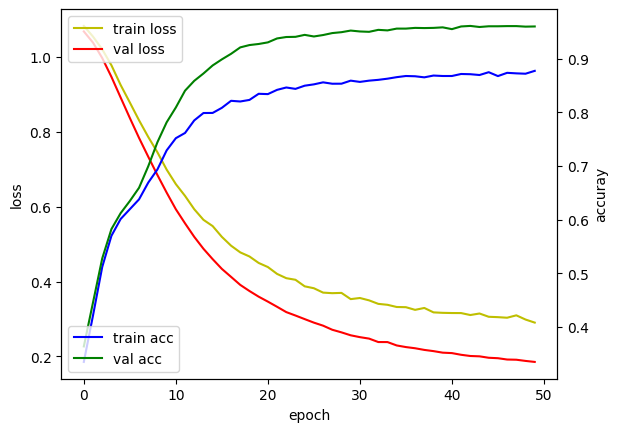

In [ ]:
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()
acc_ax = loss_ax.twinx()

loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')

acc_ax.plot(hist.history['accuracy'], 'b', label='train acc')
acc_ax.plot(hist.history['val_accuracy'], 'g', label='val acc')

loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuray')

loss_ax.legend(loc='upper left')
acc_ax.legend(loc='lower left')

plt.show()

In [ ]:
model.get_weights()

[array([[ 0.9220191 , -0.19052202,  0.05303681,  0.0439558 ,  0.8178198 ,
          0.24159074, -0.3127343 , -0.35629234],
        [-1.1054305 , -0.2895956 , -0.42364562, -0.2514302 , -1.0497    ,
         -0.5591472 ,  0.67013174, -0.5150316 ]], dtype=float32),
 array([ 0.46184322,  0.        ,  0.        ,  0.        ,  0.46425587,
         0.        , -0.30678827,  0.        ], dtype=float32),
 array([[ 0.31708592,  2.783482  ,  3.5930746 ,  3.3520494 ],
        [ 0.02461731,  0.21975368,  0.13988721, -0.5770731 ],
        [ 0.16278565,  0.20403051,  0.09508395,  0.00550234],
        [-0.08112895,  0.22256821,  0.13124007, -0.5322784 ],
        [-0.14864515,  4.050728  ,  3.7196655 ,  3.91269   ],
        [ 0.04580164,  0.5371658 ,  0.4598319 ,  0.4097672 ],
        [-0.5134735 , -0.37407747, -1.0205168 , -0.7304376 ],
        [-0.26755628, -0.19292265,  0.273996  , -0.10557598]],
       dtype=float32),
 array([-0.18515295,  0.05072089,  0.1147929 ,  0.08482154], dtype=float32),
 ar

In [ ]:
from tensorflow.keras.models import load_model

# DNN 모델을 .keras 파일로 저장 (확장자와 경로 정확히 지정)
model.save(dir + "dnn_bmi.keras")
print("Model saved to disk.")

# 저장된 모델 불러오기 (경로와 확장자 정확히 확인)
loaded_model = load_model(dir + "dnn_bmi.keras")
loaded_model.summary()

Model saved to disk.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152 (612.00 B)

 Trainable params: 75 (300.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 77 (312.00 B)

In [ ]:
# 모델을 평가하기
score = model.evaluate(X_test, y_test)
print('test_loss: ', score[0])
print('test_acc: ', score[1])

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9554 - loss: 0.1891
test_loss:  0.18906570971012115
test_acc:  0.9553999900817871


In [ ]:
# X_test 샘플들의 클래스 예측하기
y_prob = model.predict(X_test)    # X_test의 출력값 확인하기
print(y_prob[:10])

y_class = y_prob.argmax(axis=-1)  # X_test의 클래스 예측하기 (-1은 마지막 축 방향 의미)
y_class[:10]

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[2.1101744e-12 2.3898159e-01 7.6101828e-01]
 [9.2542988e-01 7.2749987e-02 1.8200328e-03]
 [8.0384125e-06 7.7891546e-01 2.2107646e-01]
 [9.4765222e-01 5.1148616e-02 1.1991728e-03]
 [5.2871055e-04 8.7661791e-01 1.2285338e-01]
 [1.0608408e-03 8.8822699e-01 1.1071223e-01]
 [1.2567906e-18 3.5247281e-02 9.6475279e-01]
 [9.4765222e-01 5.1148616e-02 1.1991728e-03]
 [1.9150581e-24 5.0047818e-03 9.9499518e-01]
 [6.3112384e-01 3.5632986e-01 1.2546304e-02]]


array([2, 0, 1, 0, 1, 1, 2, 0, 2, 0])

In [ ]:
y_prob = model.predict(X_test)  # 예측 확률
y_pred = y_prob.argmax(axis=-1)  # 예측 클래스 번호
y_true = y_test.argmax(axis=-1) # 실제 클래스 번호

# 레이블로 변환 준비
class_name = np.array(["thin", "normal", "fat"])

print("Predicted probabilities:\n", y_prob[0:10])
print("Predicted class:", y_pred[0:10], class_name[y_pred[0:10]])
print("Actual class:", y_true[0:10], class_name[y_true[0:10]])

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted probabilities:
 [[2.1101744e-12 2.3898159e-01 7.6101828e-01]
 [9.2542988e-01 7.2749987e-02 1.8200328e-03]
 [8.0384125e-06 7.7891546e-01 2.2107646e-01]
 [9.4765222e-01 5.1148616e-02 1.1991728e-03]
 [5.2871055e-04 8.7661791e-01 1.2285338e-01]
 [1.0608408e-03 8.8822699e-01 1.1071223e-01]
 [1.2567906e-18 3.5247281e-02 9.6475279e-01]
 [9.4765222e-01 5.1148616e-02 1.1991728e-03]
 [1.9150581e-24 5.0047818e-03 9.9499518e-01]
 [6.3112384e-01 3.5632986e-01 1.2546304e-02]]
Predicted class: [2 0 1 0 1 1 2 0 2 0] ['fat' 'thin' 'normal' 'thin' 'normal' 'normal' 'fat' 'thin' 'fat' 'thin']
Actual class: [2 0 1 0 1 1 2 0 2 1] ['fat' 'thin' 'normal' 'thin' 'normal' 'normal' 'fat' 'thin' 'fat'
 'normal']


In [ ]:
def normalize_samples(samples):
    samples = np.asarray(samples, dtype=np.float32).copy()
    samples[:, 0] /= 100
    samples[:, 1] /= 200
    return samples


def predict_samples(samples):
    samples = normalize_samples(samples)
    prob = model.predict(samples, verbose=0)
    pred = prob.argmax(axis=-1)
    return samples, prob, pred


# 새로운 샘플의 클래스 예측하기
X_new = [[80, 180]]
normalized_new, y_prob, y_pred = predict_samples(X_new)

print('Normalized input:', normalized_new.tolist())
print('Predicted probabilities:\n', y_prob, class_name[y_pred])
print('Predicted class:', y_pred, class_name[y_true])

Normalized input: [[0.800000011920929, 0.8999999761581421]]
Predicted probabilities:
 [[1.812648e-11 3.039383e-01 6.960617e-01]] ['fat']
Predicted class: [2] ['fat' 'thin' 'normal' ... 'thin' 'thin' 'normal']


**자신을 포함한 가족들의 BMI 측정해보기**

In [ ]:
# # 새로운 샘플의 클래스 예측하기
# X_news = np.array([[,], [,], [,], [,]], dtype=float)

# # ~~~
# # ~~~
# # ~~~

# class_name = np.array(["thin", "normal", "fat"])

# # ~~~
# # ~~~
# # ~~~


In [ ]:
# 새로운 샘플의 클래스 예측하기
X_news = np.array([[78,183], [55, 160], [50,170]], dtype=float)
X_news[:,0] /= 100
X_news[:,1] /= 200
print("Normalized input:", X_news)

# 모델을 사용하여 클래스 확률 예측
y_prob = model.predict(X_news) # X_new를 2D 배열로 전달해야 함
y_pred = y_prob.argmax(axis=-1)        # X_new의 클래스 예측하기

print("Predicted probabilities:\n", y_prob)
print("Predicted class:", y_pred)
print("Predicted label:", class_name[y_pred])

Normalized input: [[0.78  0.915]
 [0.55  0.8  ]
 [0.5   0.85 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted probabilities:
 [[3.4712655e-09 4.9881446e-01 5.0118554e-01]
 [1.5351320e-04 8.5249668e-01 1.4734985e-01]
 [9.3959695e-01 5.8982715e-02 1.4202191e-03]]
Predicted class: [2 1 0]
Predicted label: ['fat' 'normal' 'thin']


In [ ]:
X_news = [[78, 183], [55, 160], [50, 170]]
normalized_news, y_prob, y_pred = predict_samples(X_news)

print('Normalized input:', normalized_news.tolist())
print('Predicted probabilities:\n', y_prob)
print('Predicted class:', y_pred)
print('Predicted label:', class_name[y_pred])

Normalized input: [[0.7799999713897705, 0.9150000214576721], [0.550000011920929, 0.800000011920929], [0.5, 0.8500000238418579]]
Predicted probabilities:
 [[3.4712655e-09 4.9881446e-01 5.0118554e-01]
 [1.5351320e-04 8.5249668e-01 1.4734985e-01]
 [9.3959695e-01 5.8982715e-02 1.4202191e-03]]
Predicted class: [2 1 0]
Predicted label: ['fat' 'normal' 'thin']
